In [1]:
#libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
#load dataset
df = pd.read_csv("titanic.csv")

print(df.head())

   PassengerId  Survived  Pclass     Sex  Age  SibSp  Parch     Fare Embarked
0            1         0       3    male   22      1      0   7.2500        S
1            2         1       1  female   38      1      0  71.2833        C
2            3         1       3  female   26      0      0   7.9250        S
3            4         1       1  female   35      1      0  53.1000        S
4            5         0       3    male   35      0      0   8.0500        S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  45 non-null     int64  
 1   Survived     45 non-null     int64  
 2   Pclass       45 non-null     int64  
 3   Sex          45 non-null     object 
 4   Age          45 non-null     int64  
 5   SibSp        45 non-null     int64  
 6   Parch        45 non-null     int64  
 7   Fare         45 non-null     float64
 8   Embarked     45 non-null     object 
dtypes: float64(1), int64(6), object(2)
memory usage: 3.3+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000
mean,23.000000,0.511111,2.355556,27.711111,0.666667,0.511111,25.022864
std,13.133926,0.505525,0.856938,16.744907,1.022475,1.140618,20.616134
min,1.000000,0.000000,1.000000,2.000000,0.000000,0.000000,7.250000
25%,12.000000,0.000000,2.000000,14.000000,0.000000,0.000000,8.458300
50%,23.000000,1.000000,3.000000,27.000000,0.000000,0.000000,16.700000
75%,34.000000,1.000000,3.000000,38.000000,1.000000,1.000000,30.070800
max,45.000000,1.000000,3.000000,58.000000,4.000000,5.000000,80.000000


In [5]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

In [6]:
# Fill Missing Age
df["Age"] = df["Age"].fillna(df["Age"].mean())

# Fill Missing Embarked
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin
df.drop(columns=["Fare"], inplace=True)

In [7]:
print(
df.corr(
numeric_only=True
)
)

             PassengerId  Survived    Pclass       Age     SibSp     Parch
PassengerId     1.000000 -0.023961 -0.014135 -0.021288 -0.018616 -0.024274
Survived       -0.023961  1.000000 -0.219180 -0.065391 -0.234504 -0.108611
Pclass         -0.014135 -0.219180  1.000000 -0.675320  0.216154  0.344644
Age            -0.021288 -0.065391 -0.675320  1.000000 -0.591149 -0.077769
SibSp          -0.018616 -0.234504  0.216154 -0.591149  1.000000  0.227353
Parch          -0.024274 -0.108611  0.344644 -0.077769  0.227353  1.000000


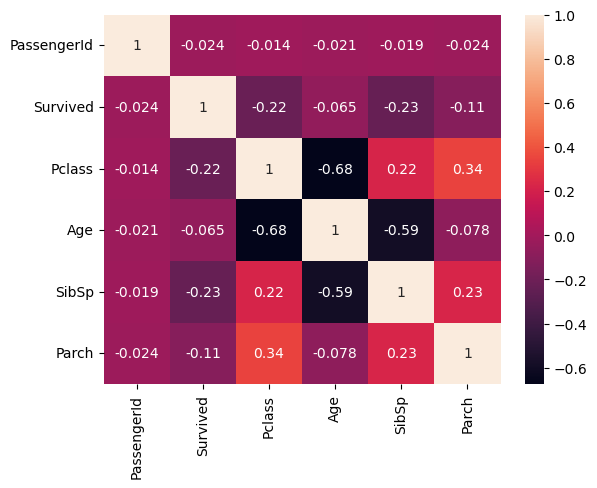

In [8]:
sns.heatmap(
    df.corr(
        numeric_only=True
    ),
    annot=True
)

plt.show()

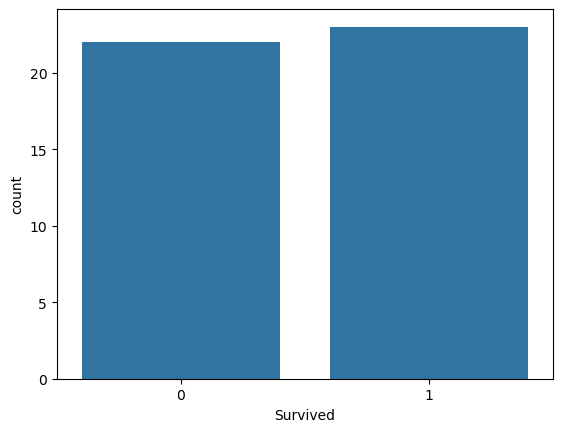

In [9]:
sns.countplot(
    x="Survived",
    data=df
)

plt.show()

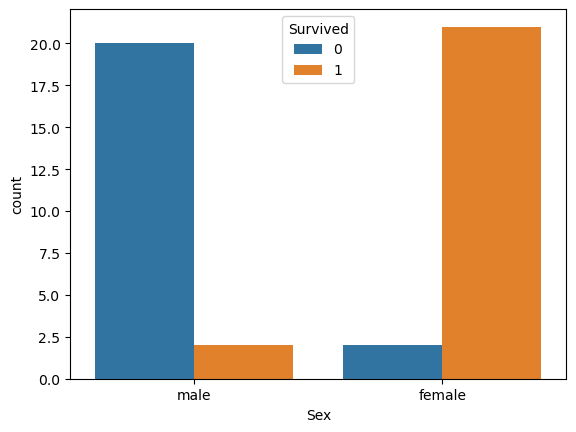

In [10]:
sns.countplot(
    x="Sex",
    hue="Survived",
    data=df
)

plt.show()

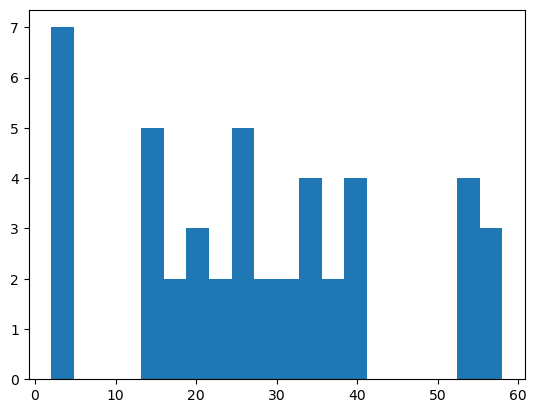

In [11]:
plt.hist(
    df["Age"],
    bins=20
)

plt.show()

In [12]:
print(df["Embarked"].unique())

['S' 'C' 'Q']


In [13]:
le = LabelEncoder()

df["Sex"] = le.fit_transform(df["Sex"])
df["Embarked"] = le.fit_transform(df["Embarked"])

In [14]:
print(df.dtypes)

PassengerId    int64
Survived       int64
Pclass         int64
Sex            int64
Age            int64
SibSp          int64
Parch          int64
Embarked       int64
dtype: object


In [17]:
X = df[
[
"Pclass",
"Sex",
"Age",
"SibSp",
"Parch",
"Embarked"
]
]

y = df["Survived"]

In [18]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [20]:
prediction = model.predict(X_test)

In [21]:
print(
    accuracy_score(
        y_test,
        prediction
    )
)

1.0


In [22]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

In [23]:
print(confusion_matrix(y_test, pred))

[[5 0]
 [0 4]]


In [24]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         4

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



In [25]:
print("prediction" in locals())
print("pred" in locals())

True
True
